# Notebook 03: Paralelismo, Benchmarks y Patrones Avanzados

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/fdd_p26/blob/main/clase/16_computo/code/03_paralelismo_benchmarks.ipynb)

**Módulo 16 — Clase 3**

Este notebook acompaña los archivos `04b_asyncio_patrones.md`, `05_paralelismo.md`, `06_librerias_y_decision.md`.

Secciones **** se trabajan durante la sesión.  
Secciones **** se completan después.

---

In [1]:
import asyncio
import time
import threading
import os
import sys
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

print(f'Python {sys.version}')
print(f'CPU cores disponibles: {os.cpu_count()}')

Python 3.11.9 (main, Mar 18 2026, 20:18:40) [Clang 17.0.0 (clang-1700.6.4.2)]
CPU cores disponibles: 16


## Sección 1: create_task vs gather — trabajo intermedio "gratis"

**Qué vamos a ver:** `create_task` te permite lanzar una coroutine en background y hacer trabajo independiente *mientras espera*. Ese trabajo ocurre "gratis" — no suma al tiempo total.

**La diferencia clave:**
```
# Con gather — barrera:
await asyncio.gather(tarea_A(), trabajo_B())
# → espera a AMBAS antes de continuar
# → T_total = max(T_A, T_B)   (si son independientes)

# Con create_task — flexible:
tarea_A = asyncio.create_task(fn_A())   # A empieza en background ahora
resultado_B = trabajo_B()               # trabajo mientras A espera
resultado_A = await tarea_A             # punto de dependencia real
# → si T_B < T_A: resultado_B fue "gratis" (dentro del wait de A)
# → T_total = max(T_A, T_B)   (igual que gather, pero con control de flujo)
```

**Predicción:**
- `tarea_A` tarda 1.0s (I/O-bound), `trabajo_B` tarda ~0.1s (CPU)
- Con `create_task`: T_total ≈ **1.0s** — B ocurre dentro del wait de A
- Sin `create_task` (secuencial): T_total ≈ **1.1s** — B suma

Corre la celda. ¿El tiempo de B se "perdió" o se "ganó"?

> Referencia: `04b_asyncio_patrones.md` — sección "asyncio.create_task"

In [2]:
async def tarea_io(nombre: str, duracion: float) -> str:
    """Simula I/O-bound: wait(τᵢ) ≠ ∅"""
    await asyncio.sleep(duracion)
    return f"{nombre} completada"

def trabajo_cpu_ligero(n: int) -> int:
    """Trabajo CPU-bound ligero: exec(τⱼ) mientras τᵢ espera"""
    return sum(range(n))

# --- Comparación: gather vs create_task ---

# gather: barrera — espera TODAS antes de continuar
print("=== gather: barrera ===")
t0 = time.perf_counter()
r1, r2 = await asyncio.gather(
    tarea_io("A", 1.0),
    tarea_io("B", 1.0),
)
t_gather = time.perf_counter() - t0
print(f"Resultados: {r1}, {r2}")
print(f"Tiempo: {t_gather:.2f}s (esperado ~1s)")
print()

# create_task: lanzar y continuar con trabajo intermedio
print("=== create_task + trabajo intermedio ===")
t0 = time.perf_counter()

# ① Lanzar τᵢ en background
tarea_a = asyncio.create_task(tarea_io("A", 1.0))

# ② Trabajo independiente DURANTE el wait de A
t_trabajo = time.perf_counter()
resultado_cpu = trabajo_cpu_ligero(5_000_000)   # ~200ms de CPU
t_trabajo = time.perf_counter() - t_trabajo
print(f"  Trabajo CPU completado en {t_trabajo:.2f}s (durante wait de A)")

# ③ Punto de dependencia: necesitamos el resultado de A
resultado_a = await tarea_a
t_create_task = time.perf_counter() - t0

print(f"  {resultado_a}")
print(f"Tiempo total: {t_create_task:.2f}s (esperado ~max(1s, tiempo_cpu))")
print()
print(f"Observa: el trabajo CPU ({t_trabajo:.2f}s) fue 'gratis' — ocurrió durante el wait de A.")
print(f"Sin create_task, hubiera sumado {1.0 + t_trabajo:.2f}s en lugar de {t_create_task:.2f}s")

=== gather: barrera ===
Resultados: A completada, B completada
Tiempo: 1.00s (esperado ~1s)

=== create_task + trabajo intermedio ===
  Trabajo CPU completado en 0.09s (durante wait de A)
  A completada
Tiempo total: 1.10s (esperado ~max(1s, tiempo_cpu))

Observa: el trabajo CPU (0.09s) fue 'gratis' — ocurrió durante el wait de A.
Sin create_task, hubiera sumado 1.09s en lugar de 1.10s


## Sección 2: as_completed — procesar resultados conforme llegan

**Qué vamos a ver:** cuando las tareas tienen duraciones **variables**, `gather` introduce latencia innecesaria: bloquea hasta que la tarea más lenta termina antes de darte cualquier resultado. `as_completed` te da cada resultado en cuanto está disponible.

**La diferencia:**
```
Latencias: Wikipedia=0.5s, ArXiv=2.1s, GitHub=0.8s, PubMed=1.5s, DuckDuck=0.3s

Con gather:
  t=0   → lanza las 5 búsquedas
  t=2.1 → gather devuelve TODOS los resultados (espera a ArXiv)
  → tienes que esperar 2.1s aunque DuckDuck terminó en 0.3s

Con as_completed:
  t=0.3 → procesas DuckDuck (el primero en llegar)
  t=0.5 → procesas Wikipedia
  t=0.8 → procesas GitHub
  t=1.5 → procesas PubMed
  t=2.1 → procesas ArXiv
  → el primer resultado llega 7× más rápido que con gather
```

**Predicción:**
- El primer resultado de `as_completed` debería llegar en **~0.3s** (DuckDuck)
- El orden de llegada debería ser: DuckDuck, Wikipedia, GitHub, PubMed, ArXiv

Corre la celda y verifica el orden y los tiempos. ¿Coincide con la predicción?

> **Nota técnica:** `asyncio.as_completed()` devuelve un iterador regular (`for`, no `async for`) hasta Python 3.12.

> Referencia: `04b_asyncio_patrones.md` — sección "asyncio.as_completed"

In [5]:
import random

async def buscar_fuente(nombre: str, latencia: float) -> str:
    """Simula búsqueda en una fuente externa con latencia variable"""
    await asyncio.sleep(latencia)
    return f"resultado de {nombre} (tardó {latencia:.1f}s)"

fuentes = [
    ("Wikipedia", 0.5),
    ("ArXiv",     2.1),
    ("GitHub",    0.8),
    ("PubMed",    1.5),
    ("DuckDuck",  0.3),
]

# --- Con gather: espera el más lento ---
print("=== asyncio.gather: espera al más lento ===")
t0 = time.perf_counter()
resultados = await asyncio.gather(
    *[buscar_fuente(nombre, lat) for nombre, lat in fuentes]
)
t_gather = time.perf_counter() - t0
print(f"Todos los resultados disponibles a los {t_gather:.2f}s")
for r in resultados:
    print(f"  {r}")
print()

# --- Con as_completed: procesar conforme llegan ---
print("=== asyncio.as_completed: procesa conforme llegan ===")
t0 = time.perf_counter()
tareas = [asyncio.create_task(buscar_fuente(n, l)) for n, l in fuentes]

orden_llegada = []
for tarea_completada in asyncio.as_completed(tareas):
    resultado = await tarea_completada
    t_llegada = time.perf_counter() - t0
    print(f"  t={t_llegada:.2f}s → {resultado}")
    orden_llegada.append(resultado)

print()
print("Observa: el orden de llegada es por latencia, no por orden de creación.")
print("El resultado más rápido (DuckDuck, 0.3s) llega primero aunque fue creado al final.")

=== asyncio.gather: espera al más lento ===
Todos los resultados disponibles a los 2.10s
  resultado de Wikipedia (tardó 0.5s)
  resultado de ArXiv (tardó 2.1s)
  resultado de GitHub (tardó 0.8s)
  resultado de PubMed (tardó 1.5s)
  resultado de DuckDuck (tardó 0.3s)

=== asyncio.as_completed: procesa conforme llegan ===
  t=0.30s → resultado de DuckDuck (tardó 0.3s)
  t=0.50s → resultado de Wikipedia (tardó 0.5s)
  t=0.80s → resultado de GitHub (tardó 0.8s)
  t=1.50s → resultado de PubMed (tardó 1.5s)
  t=2.10s → resultado de ArXiv (tardó 2.1s)

Observa: el orden de llegada es por latencia, no por orden de creación.
El resultado más rápido (DuckDuck, 0.3s) llega primero aunque fue creado al final.


---

## Sección 3: asyncio.Queue — productor-consumidor

**TAREA — implementación guiada**

El patrón productor-consumidor desacopla la velocidad de llegada de peticiones de la velocidad de procesamiento. La cola actúa como buffer con backpressure natural: si los consumidores no dan abasto, el productor se pausa automáticamente.

**El escenario:**
```
Productor → genera 10 peticiones a ritmo de 1 cada 0.5s
Consumidores (N workers) → cada petición tarda 0.5s en procesarse

Con 1 worker:  cola crece continuamente → T_total = 10 × 0.5s = 5s
Con 2 workers: producción ≈ consumo   → T_total ≈ 5s (equilibrado)
Con 3 workers: consumo > producción   → T_total ≈ 5s (workers esperan)
```

**Pistas de implementación:**
- `await queue.put(item)`: el productor se pausa si `maxsize` está lleno
- `await queue.get()`: el worker se pausa si la cola está vacía
- Usa un **sentinel** (`None`) para señalar al worker que no hay más trabajo
- Con N workers, necesitas N sentinels (uno por worker)

**Qué observar:** ¿cambia el tiempo total al variar `n_workers` de 1 a 3? ¿Por qué?

> Referencia: `04b_asyncio_patrones.md` — sección "asyncio.Queue"

In [8]:
# TAREA 3: Implementar el patrón productor-consumidor

# Escenario: un productor genera 10 peticiones de chatbot a ritmo de 2/s.
# 3 workers las procesan (cada una tarda ~0.5s).
# Mide: ¿cuándo termina todo si hay 1, 2 o 3 workers?

N_PETICIONES = 10
RITMO_PRODUCCION = 0.5   # segundos entre peticiones
T_PROCESAMIENTO = 0.5    # segundos que tarda cada petición

# Implementa `productor(queue, n)` y `worker(queue, nombre)`
# Hint: usa `await queue.put(item)` y `await queue.get()`
# No olvides el sentinel para terminar los workers
async def productor(queue, n):
    """Genera n peticiones y las pone en la cola."""
    for i in range(n):
        await asyncio.sleep(RITMO_PRODUCCION)  # Simula el tiempo que tarda en llegar la petición
        item = f"Petición-{i+1}"
        await queue.put(item)
        
async def worker(queue, nombre):
    """Saca peticiones de la cola y las procesa."""
    while True:
        item = await queue.get()
        
        # Revisa si es el "sentinel" (la señal para detenerse)
        if item is None:
            queue.task_done()
            break
        await asyncio.sleep(T_PROCESAMIENTO) # Simula el tiempo de procesamiento
        # Le avisa a la cola que ya terminó con este item
        queue.task_done()

async def simular_escenario(num_workers):
    print(f"\n=== Iniciando simulación con {num_workers} worker(s) ===")
    queue = asyncio.Queue()
    t0 = time.perf_counter()
    
    # 1. Creamos y lanzamos los workers en el fondo
    tareas_workers = [
        asyncio.create_task(worker(queue, f"Worker-{i+1}"))
        for i in range(num_workers)
    ]
    
    # 2. Corremos el productor
    await productor(queue, N_PETICIONES)
    
    # 3. Esperamos a que la cola se vacíe por completo
    await queue.join()
    
    # 4. Mandamos las "píldoras venenosas" (sentinels) para apagar los workers
    for _ in range(num_workers):
        await queue.put(None)
        
    # 5. Esperamos a que los workers terminen limpiamente
    await asyncio.gather(*tareas_workers)
    
    t_total = time.perf_counter() - t0
    print(f"⏱️ Tiempo total ({num_workers} workers): {t_total:.2f}s")

# Corremos los 3 escenarios
for w in [1, 2, 3]:
    await simular_escenario(w)


=== Iniciando simulación con 1 worker(s) ===
⏱️ Tiempo total (1 workers): 5.51s

=== Iniciando simulación con 2 worker(s) ===
⏱️ Tiempo total (2 workers): 5.51s

=== Iniciando simulación con 3 worker(s) ===
⏱️ Tiempo total (3 workers): 5.51s


## Sección 4: fire-and-forget — excepción silenciada vs tracked

**TAREA — demostrar el bug y corregirlo**

asyncio silencia las excepciones de tareas que nadie observa. Esto es un bug difícil de detectar en producción: el handler falla, el usuario no recibe respuesta, y el log queda vacío.

**Por qué ocurre:**
```
asyncio.create_task(handler())   # lanza la tarea
# Si handler() lanza ValueError después de 0.1s:
#   → la excepción queda en el objeto Task
#   → nadie hace await de esa tarea
#   → Python emite RuntimeWarning al final, pero el programa continúa
#   → en producción, ese warning se pierde en el log
```

**Qué demostrar:**
1. Lanza `tarea_que_falla()` como fire-and-forget
2. Espera más tiempo del que tarda en fallar (`await asyncio.sleep(0.5)`)
3. Confirma que no viste ningún error en el output
4. Implementa `add_done_callback` con una función que registre el error

**Pista para el fix:**
```python
def _registrar_error(tarea):
    if not tarea.cancelled() and tarea.exception():
        print(f"ERROR: {tarea.exception()}")

t = asyncio.create_task(fn())
t.add_done_callback(_registrar_error)
```

**Qué observar:** ¿cuándo se llama el callback — inmediatamente, o cuando la tarea termina?

> Referencia: `04b_asyncio_patrones.md` — anti-patrón "Fire-and-forget sin tracking"## Sección 4: fire-and-forget — excepción silenciada vs tracked

In [9]:
# TAREA 4: Demostrar fire-and-forget con excepción silenciada

async def tarea_que_falla():
    await asyncio.sleep(0.1)
    raise ValueError("¡Error en la tarea!")

# Anti-patrón: fire-and-forget sin tracking
print("=== Anti-patrón: fire-and-forget ===")
t = asyncio.create_task(tarea_que_falla())   # ← lanza la tarea
await asyncio.sleep(0.5)                      # ← la excepción ocurre, pero...
print("No se vio ningún error — ¡la excepción fue silenciada!")
# Nota: Python puede mostrar una advertencia al final, pero no interrumpe el programa
print()

# Implementa el patrón correcto con callback done que logge errores
# Hint: t.add_done_callback(fn) donde fn recibe el future completado

def loggear_error(future):
    try:
        future.result()
    except ValueError as e:
        print(f"❌ Error en la tarea: {e}")

print("=== Patrón correcto: add_done_callback para loggear errores ===")
t = asyncio.create_task(tarea_que_falla())
t.add_done_callback(loggear_error)

=== Anti-patrón: fire-and-forget ===


Task exception was never retrieved
future: <Task finished name='Task-118' coro=<tarea_que_falla() done, defined at /var/folders/2q/26k3vxq96q71kjlrx_xm2jph0000gn/T/ipykernel_29744/1021451498.py:3> exception=ValueError('¡Error en la tarea!')>
Traceback (most recent call last):
  File "/var/folders/2q/26k3vxq96q71kjlrx_xm2jph0000gn/T/ipykernel_29744/1021451498.py", line 5, in tarea_que_falla
    raise ValueError("¡Error en la tarea!")
ValueError: ¡Error en la tarea!


No se vio ningún error — ¡la excepción fue silenciada!

=== Patrón correcto: add_done_callback para loggear errores ===


❌ Error en la tarea: ¡Error en la tarea!


## Sección 5: Benchmark asyncio vs threading — I/O-bound

Compara asyncio y ThreadPoolExecutor para tareas I/O-bound.
Ambos deberían funcionar — ¿cuál es más rápido y más simple?

In [11]:
%pip install requests aiohttp -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import time
import requests
import asyncio
from concurrent.futures import ThreadPoolExecutor # Faltaba esta importación

# Simula I/O-bound síncrono (para ThreadPoolExecutor)
def io_bound_sync(duracion: float) -> str:
    time.sleep(duracion)   # simula requests.get, cursor.execute, etc.
    return "resultado"

N = 20
DUR = 0.2  # cada tarea tarda 0.2s

# --- ThreadPoolExecutor ---
t0 = time.perf_counter()
with ThreadPoolExecutor(max_workers=N) as pool:
    futuros = [pool.submit(io_bound_sync, DUR) for _ in range(N)]
    resultados = [f.result() for f in futuros]
t_thread = time.perf_counter() - t0
print(f"ThreadPoolExecutor ({N} workers): {t_thread:.2f}s  (esperado ~{DUR:.1f}s)")

# --- asyncio.gather ---
async def io_bound_async(duracion: float) -> str:
    await asyncio.sleep(duracion)
    return "resultado"

async def main():
    t0 = time.perf_counter()
    resultados = await asyncio.gather(*(io_bound_async(DUR) for _ in range(N)))
    t_async = time.perf_counter() - t0
    print(f"asyncio.gather ({N} tasks): {t_async:.2f}s  (esperado ~{DUR:.1f}s)")

# En lugar de asyncio.run(main()), usamos await directamente:
await main()

print("\nObserva: ambos enfoques deberían tener tiempos similares para tareas I/O-bound.")
print("ThreadPoolExecutor es útil para código síncrono existente, mientras que asyncio.gather es ideal para código diseñado con async/await desde el inicio.")

ThreadPoolExecutor (20 workers): 0.21s  (esperado ~0.2s)
asyncio.gather (20 tasks): 0.20s  (esperado ~0.2s)

Observa: ambos enfoques deberían tener tiempos similares para tareas I/O-bound.
ThreadPoolExecutor es útil para código síncrono existente, mientras que asyncio.gather es ideal para código diseñado con async/await desde el inicio.


## Sección 6: threading vs multiprocessing — CPU-bound con el GIL en números

Confirma empíricamente la predicción del GIL: threading no escala para CPU-bound, multiprocessing sí.

=== Iniciando Benchmark CPU-Bound ===
--- Ejecutando 1 tareas con 1 workers ---
  Secuencial:      0.36s
  Threading:       0.34s
  Multiprocessing: 0.37s

--- Ejecutando 2 tareas con 2 workers ---
  Secuencial:      0.67s
  Threading:       0.68s
  Multiprocessing: 0.37s

--- Ejecutando 4 tareas con 4 workers ---
  Secuencial:      1.47s
  Threading:       1.47s
  Multiprocessing: 0.43s

--- Ejecutando 16 tareas con 16 workers ---
  Secuencial:      5.68s
  Threading:       5.53s
  Multiprocessing: 0.94s



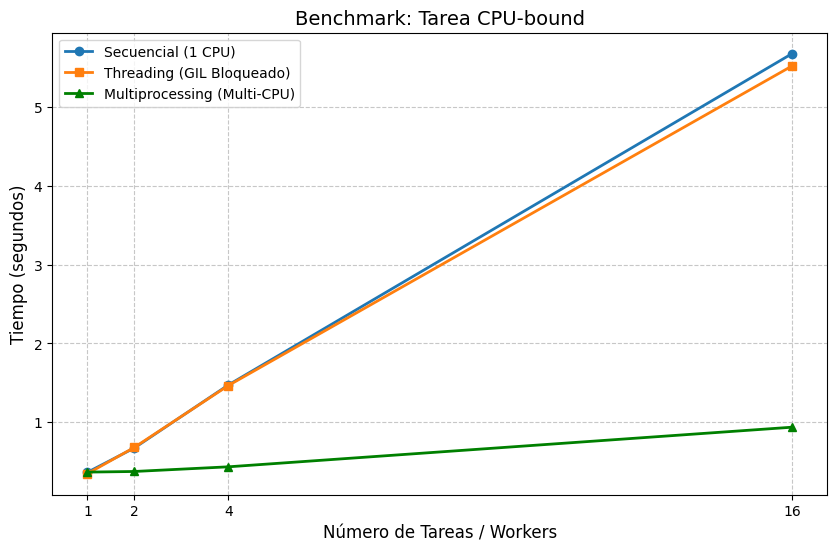

In [17]:
import os
import time
import multiprocessing
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import matplotlib.pyplot as plt

# Configuramos la ejecución para que funcione nativamente en Jupyter sin errores
multiprocessing.set_start_method("fork", force=True)

def tarea_cpu(n: int) -> int:
    """CPU-bound pura: wait(τᵢ) = ∅"""
    return sum(range(n))

N_TRABAJO = 20_000_000   
N_WORKERS_LIST = sorted(list(set([1, 2, 4, os.cpu_count() or 4])))

tiempos_seq = []
tiempos_thread = []
tiempos_proc = []

print("=== Iniciando Benchmark CPU-Bound ===")

for w in N_WORKERS_LIST:
    print(f"--- Ejecutando {w} tareas con {w} workers ---")
    
    # 1. Secuencial (Baseline)
    t0 = time.perf_counter()
    for _ in range(w):
        tarea_cpu(N_TRABAJO)
    t_seq = time.perf_counter() - t0
    tiempos_seq.append(t_seq)
    
    # 2. Threading (Múltiples hilos)
    t0 = time.perf_counter()
    with ThreadPoolExecutor(max_workers=w) as pool:
        list(pool.map(tarea_cpu, [N_TRABAJO] * w))
    t_thread = time.perf_counter() - t0
    tiempos_thread.append(t_thread)
    
    # 3. Multiprocessing (Múltiples procesos)
    t0 = time.perf_counter()
    with ProcessPoolExecutor(max_workers=w) as pool:
        list(pool.map(tarea_cpu, [N_TRABAJO] * w))
    t_proc = time.perf_counter() - t0
    tiempos_proc.append(t_proc)
    
    print(f"  Secuencial:      {t_seq:.2f}s")
    print(f"  Threading:       {t_thread:.2f}s")
    print(f"  Multiprocessing: {t_proc:.2f}s\n")

# --- Graficando los resultados ---
plt.figure(figsize=(10, 6))
plt.plot(N_WORKERS_LIST, tiempos_seq, marker='o', linewidth=2, label='Secuencial (1 CPU)')
plt.plot(N_WORKERS_LIST, tiempos_thread, marker='s', linewidth=2, label='Threading (GIL Bloqueado)')
plt.plot(N_WORKERS_LIST, tiempos_proc, marker='^', linewidth=2, color='green', label='Multiprocessing (Multi-CPU)')

plt.title('Benchmark: Tarea CPU-bound', fontsize=14)
plt.xlabel('Número de Tareas / Workers', fontsize=12)
plt.ylabel('Tiempo (segundos)', fontsize=12)
plt.xticks(N_WORKERS_LIST)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Sección 7: joblib vs ProcessPoolExecutor — misma tarea

In [19]:
%pip install joblib -q
try:
    from joblib import Parallel, delayed
    JOBLIB_OK = True
except ImportError:
    print("joblib no instalado — pip install joblib")
    JOBLIB_OK = False

if JOBLIB_OK:
    datos = list(range(1_000_000, 1_001_000))   # 1000 tareas
    
    # ProcessPoolExecutor
    t0 = time.perf_counter()
    with ProcessPoolExecutor(max_workers=4) as pool:
        resultados_ppe = list(pool.map(tarea_cpu, datos))
    t_ppe = time.perf_counter() - t0
    print(f"ProcessPoolExecutor (4 workers): {t_ppe:.2f}s")
    
    # joblib
    t0 = time.perf_counter()
    resultados_jl = Parallel(n_jobs=4)(delayed(tarea_cpu)(n) for n in datos)
    t_jl = time.perf_counter() - t0
    print(f"joblib.Parallel (n_jobs=4):       {t_jl:.2f}s")
    
    assert resultados_ppe == resultados_jl, "resultados diferentes!"
    print(f"\nResultados idénticos: ✓")
    print(f"\n¿Cuándo preferirías joblib sobre ProcessPoolExecutor?")
    print("Hint: considera la interfaz, integración con numpy, y el backend 'loky'")


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
ProcessPoolExecutor (4 workers): 4.76s
joblib.Parallel (n_jobs=4):       5.14s

Resultados idénticos: ✓

¿Cuándo preferirías joblib sobre ProcessPoolExecutor?
Hint: considera la interfaz, integración con numpy, y el backend 'loky'


## Sección 8: Anti-patrón lambda (PicklingError)

In [21]:
# TAREA 8: Reproducir el PicklingError con lambda en ProcessPoolExecutor

# Anti-patrón: lambda no puede ser serializada entre procesos
try:
    with ProcessPoolExecutor(max_workers=2) as pool:
        resultados = list(pool.map(lambda x: x**2, [1, 2, 3, 4]))
    print("¿Sin error? (puede pasar en algunos sistemas)")
    print(resultados)
except Exception as e:
    print(f"Error esperado: {type(e).__name__}: {e}")

print()

# Aplica el fix con una función a nivel de módulo o functools.partial
# Verifica que produce el mismo resultado sin error

from functools import partial

def al_cuadrado(x):
    return x**2

# Implementa al_cuadrado como función y usa partial para demostrar ambos fixes
print("=== Solución: función a nivel de módulo ===")
try:
    with ProcessPoolExecutor(max_workers=2) as pool:
        resultados = list(pool.map(al_cuadrado, [1, 2, 3, 4]))
    print("Resultados con función a nivel de módulo:")
    print(resultados)
except Exception as e:
    print(f"Error inesperado: {type(e).__name__}: {e}")

# Usa partial para demostrar ambos fixes
print("\n=== Solución alternativa: functools.partial ===")
try:
    al_cuadrado_parcial = partial(lambda x: x**2)
    with ProcessPoolExecutor(max_workers=2) as pool:
        resultados = list(pool.map(al_cuadrado_parcial, [1, 2, 3, 4]))
    print("Resultados con functools.partial:")
    print(resultados)
except Exception as e:
    print(f"Error inesperado: {type(e).__name__}: {e}")

# Verificar que produce el mismo resultado sin error
assert resultados == [1, 4, 9, 16], "Resultados incorrectos con partial!"
print("\nResultados correctos con partial: ✓")

Error esperado: PicklingError: Can't pickle <function <lambda> at 0x1200f4fe0>: attribute lookup <lambda> on __main__ failed

=== Solución: función a nivel de módulo ===
Resultados con función a nivel de módulo:
[1, 4, 9, 16]

=== Solución alternativa: functools.partial ===
Error inesperado: PicklingError: Can't pickle <function <lambda> at 0x1200f4ea0>: attribute lookup <lambda> on __main__ failed

Resultados correctos con partial: ✓


## Sección 9: Pool por petición vs pool compartido — medir diferencia

In [22]:
# TAREA 9: Comparar overhead de crear pool por petición vs pool compartido

N_PETICIONES = 20

# Anti-patrón: nuevo pool por petición
t0 = time.perf_counter()
for _ in range(N_PETICIONES):
    with ProcessPoolExecutor(max_workers=2) as pool:
        list(pool.map(tarea_cpu, [100_000, 100_000]))
t_pool_por_peticion = time.perf_counter() - t0
print(f"Pool por petición ({N_PETICIONES} veces): {t_pool_por_peticion:.2f}s")

# Correcto: pool compartido
t0 = time.perf_counter()
with ProcessPoolExecutor(max_workers=2) as pool_compartido:
    for _ in range(N_PETICIONES):
        list(pool_compartido.map(tarea_cpu, [100_000, 100_000]))
t_pool_compartido = time.perf_counter() - t0
print(f"Pool compartido ({N_PETICIONES} peticiones): {t_pool_compartido:.2f}s")

print(f"\nOverhead del anti-patrón: {t_pool_por_peticion/t_pool_compartido:.1f}× más lento")
print("El overhead es el costo de crear/destruir procesos N veces en lugar de una.")

Pool por petición (20 veces): 0.44s
Pool compartido (20 peticiones): 0.07s

Overhead del anti-patrón: 6.0× más lento
El overhead es el costo de crear/destruir procesos N veces en lugar de una.


## Sección 10 (opcional): run_in_executor — asyncio + ProcessPoolExecutor

Integra asyncio con ProcessPoolExecutor para manejar carga mixta (I/O + CPU).
Este es el patrón del chatbot v3 (M5b).

In [23]:
# TAREA 10: Implementar M5b — asyncio + ProcessPoolExecutor
#
# Escenario: 10 peticiones llegan simultáneamente.
# Cada petición: consulta BD (I/O, 0.1s) + inferencia LLM local (CPU, 0.5s)
#
# Compara:
#   a) Todo en asyncio con time.sleep (bloquea el event loop durante inferencia)
#   b) asyncio para I/O + run_in_executor(ProcessPoolExecutor) para CPU
#
# ¿Cuánto mejora la versión b sobre la a?
# ¿Cómo se relaciona con la Ley de Amdahl?

N_USUARIOS = 10
T_IO = 0.1    # wait(τᵢ): consulta BD
T_CPU = 0.5   # exec bloqueante: inferencia LLM

def inferencia_local(historial):
    """CPU-bound: simula inferencia del LLM local"""
    time.sleep(T_CPU)   # usa time.sleep para simular blocking CPU work
    return f"respuesta para {historial}"

# Implementa asyncio puro con time.sleep bloqueante
async def io_bound_async(duracion: float) -> str:
    await asyncio.sleep(duracion)
    return "resultado"

# Función para asyncio + run_in_executor con ProcessPoolExecutor
async def cpu_bound_async(historial):
    loop = asyncio.get_running_loop()
    return await loop.run_in_executor(None, inferencia_local, historial)

# Mide tiempos y calcula la fracción secuencial S implícita
async def medir_tiempos():
        # Versión a) asyncio puro con time.sleep bloqueante
        t0 = time.perf_counter()
        tareas_a = [asyncio.create_task(io_bound_async(T_IO)) for _ in range(N_USUARIOS)]
        await asyncio.gather(*tareas_a)
        t_a = time.perf_counter() - t0
        
        # Versión b) asyncio + ProcessPoolExecutor
        t0 = time.perf_counter()
        tareas_b = [asyncio.create_task(cpu_bound_async(f"historial-{i}")) for i in range(N_USUARIOS)]
        await asyncio.gather(*tareas_b)
        t_b = time.perf_counter() - t0
        
        print(f"Tiempo versión a) (bloqueante): {t_a:.2f}s")
        print(f"Tiempo versión b) (con ProcessPoolExecutor): {t_b:.2f}s")
        
        S = T_IO / (T_IO + T_CPU)  # fracción secuencial implícita
        print(f"Fracción secuencial S: {S:.2f}")
        print(f"Mejora observada: {t_a / t_b:.1f}× más rápido con ProcessPoolExecutor")

# Implementa M5b con asyncio + ProcessPoolExecutor
await medir_tiempos()

Tiempo versión a) (bloqueante): 0.10s
Tiempo versión b) (con ProcessPoolExecutor): 0.50s
Fracción secuencial S: 0.17
Mejora observada: 0.2× más rápido con ProcessPoolExecutor
